In [3]:
import pandas as pd
import numpy as np
import os
import glob 
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Parser

In [4]:
# Reads in the MPA file and returns the realtime and totalsum values
def read_mpa_file(filepath):
    realtime = None
    totalsum = None

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())

    return realtime, totalsum

# Gets the HV value from the filename
def get_hv(filename):
    name_only = filename.replace("HV", "").replace(".mpa", "")
    name_only = name_only.split("_")[0]
    return int(name_only)

def get_run(filename):
    name_only = filename.replace("HV", "").replace(".mpa", "")
    if "_" in name_only:
        return int(name_only.split("_")[1])
    return 1

data_folder = "HVControl"
rows = []

for filepath in glob.glob(os.path.join(data_folder, "HV*.mpa")):
    filename = os.path.basename(filepath)

    hv = get_hv(filename)
    run = get_run(filename)
    realtime, totalsum = read_mpa_file(filepath)
    rate = totalsum / realtime

    if run not in (5,6, 7):
        continue # skips the old run 1/2 files (floating potential wasn't on), run 3 as it was operated at a higher current, and run 4 was using a non-ideal PSU

    rows.append({
        "hv_volts": hv,
        "run": run,
        "file": filename,
        "realtime_s": realtime,
        "totalsum": totalsum,
        "rate_hz": rate
    })

df = pd.DataFrame(rows).sort_values(["run", "hv_volts"]).reset_index(drop = True)

def get_tdc_threshold(filename):
    name_only = filename.replace("TDCNoise", "").replace(".mpa", "")
    return int(name_only)

def get_dark_info(filename):
    name_only = filename.replace("DarkCount", "").replace(".mpa", "") 
    hv_str, threshold_str = name_only.split("_")
    return int(hv_str), int(threshold_str)

tdc_noise_lookup = {}
for filepath in glob.glob(os.path.join(data_folder, "TDCNoise*.mpa")):
    filename = os.path.basename(filepath)
    threshold_mv = get_tdc_threshold(filename)
    realtime, totalsum = read_mpa_file(filepath)
    rate = totalsum / realtime
    err = np.sqrt(totalsum) / realtime
    tdc_noise_lookup[threshold_mv] = (rate, err)

dark_rows = []
for filepath in glob.glob(os.path.join(data_folder, "DarkCount*.mpa")):
    filename = os.path.basename(filepath)
    hv, threshold_mv = get_dark_info(filename)
    realtime, totalsum = read_mpa_file(filepath)
    rate = totalsum / realtime
    err = np.sqrt(totalsum) / realtime
    dark_rows.append({
        "hv_volts": hv,
        "threshold_mv": threshold_mv,
        "file": filename,
        "realtime_s": realtime,
        "totalsum": totalsum,
        "rate_hz": rate,
        "rate_err_hz": err
    })

dark_df = pd.DataFrame(dark_rows).sort_values(["threshold_mv", "hv_volts"]).reset_index(drop = True)
dark_df['tdc_noise_rate'] = dark_df['threshold_mv'].map(lambda t: tdc_noise_lookup[t][0])
dark_df['tdc_noise_err'] = dark_df['threshold_mv'].map(lambda t: tdc_noise_lookup[t][1])
dark_df['rate_minus_tdc_hz'] = dark_df['rate_hz'] - dark_df['tdc_noise_rate']

dark_fits = {}
dark_fits_rms = {}

for threshold_mv, group in dark_df.groupby("threshold_mv"):
    coeffs = np.polyfit(group["hv_volts"], group["rate_minus_tdc_hz"], 1)
    fit = np.poly1d(coeffs)
    residuals = group["rate_minus_tdc_hz"] - fit(group["hv_volts"])
    dark_fits[threshold_mv] = fit
    dark_fits_rms[threshold_mv] = np.sqrt(np.mean(residuals**2))

dark_df['total_error_hz'] = np.sqrt(dark_df['rate_err_hz']**2 + dark_df['tdc_noise_err']**2 + dark_df['threshold_mv'].map(lambda t: dark_fits_rms[t])**2)

In [5]:
run_to_threshold = {5: 7, 6: 7, 7:5}

def correct_row(row):
    threshold_mv = run_to_threshold[row['run']]
    tdc_rate, tdc_err = tdc_noise_lookup[threshold_mv]
    dark_fit = dark_fits[threshold_mv]
    fit_rms = dark_fits_rms[threshold_mv]

    dark_rate_at_hv = dark_fit(row['hv_volts'])
    rate_corrected = row['rate_hz'] - tdc_rate - dark_rate_at_hv

    stat_err = np.sqrt(row['totalsum']) / row['realtime_s']
    total_err = np.sqrt(stat_err**2 + tdc_err**2 + fit_rms**2)

    return pd.Series({"rate_corrected_hz": rate_corrected, "total_error_hz": total_err})
df[['rate_corrected_hz', 'total_error_hz']] = df.apply(correct_row, axis=1)

# Corrected Runs

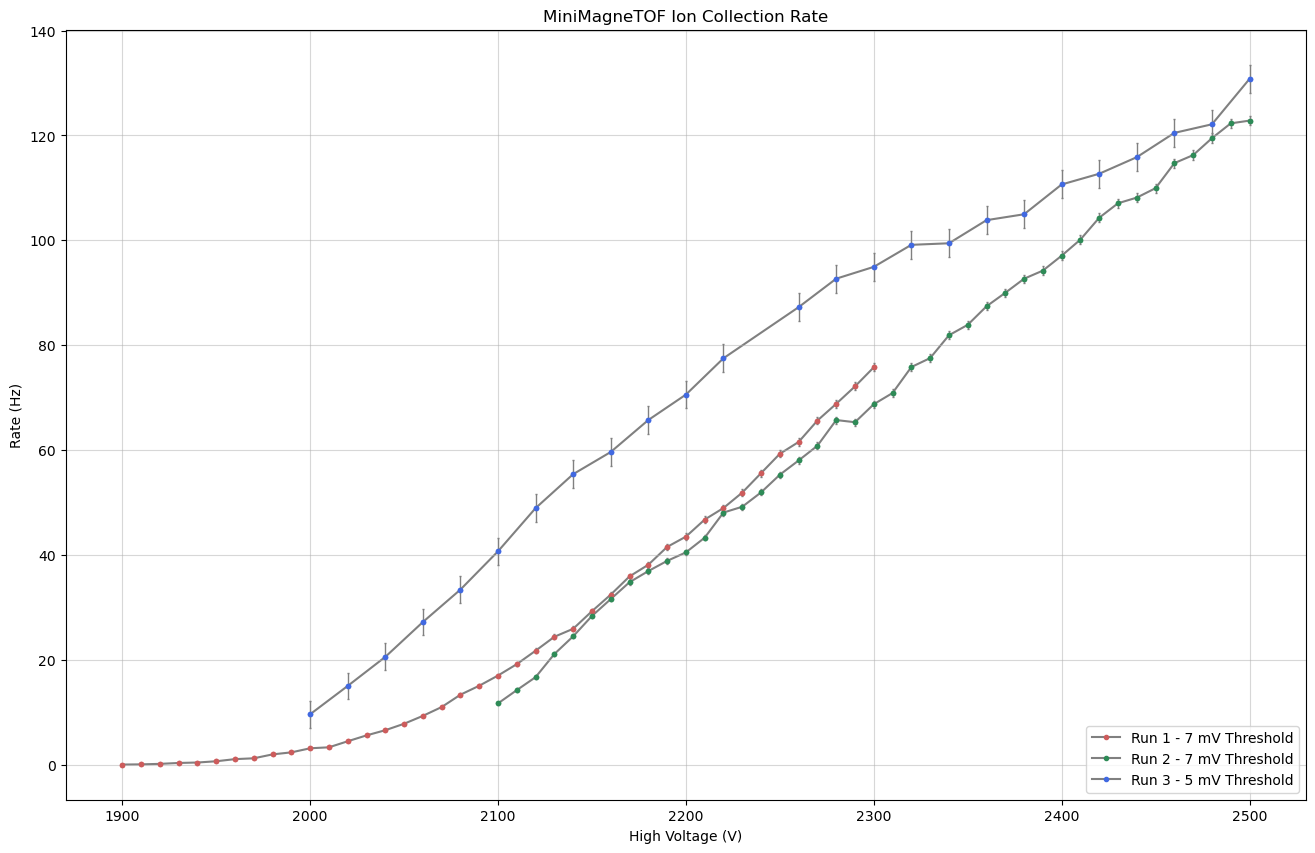

In [6]:
fig, ax = plt.subplots(figsize=(16, 10))

run5 = df[df["run"] == 5]
run6 = df[df["run"] == 6]
run7 = df[df["run"] == 7]

# Run 5 Points:
ax.plot(run5["hv_volts"], run5["rate_corrected_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=3, markerfacecolor='indianred', markeredgecolor='indianred', label="Run 1 - 7 mV Threshold")
ax.errorbar(run5["hv_volts"], run5["rate_corrected_hz"], yerr=run5["total_error_hz"], fmt='o', markersize=3, color='indianred', ecolor='gray', elinewidth=1, capsize=1)
# Run 6 Points:
ax.plot(run6["hv_volts"], run6["rate_corrected_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=3, markerfacecolor='seagreen', markeredgecolor='seagreen', label="Run 2 - 7 mV Threshold")
ax.errorbar(run6["hv_volts"], run6["rate_corrected_hz"], yerr=run6["total_error_hz"], fmt='o', markersize=3, color='seagreen', ecolor='gray', elinewidth=1, capsize=1)
# Run 7 Points:
ax.plot(run7["hv_volts"], run7["rate_corrected_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=3, markerfacecolor='royalblue', markeredgecolor='royalblue', label="Run 3 - 5 mV Threshold")
ax.errorbar(run7["hv_volts"], run7["rate_corrected_hz"], yerr=run7["total_error_hz"], fmt='o', markersize=3, color='royalblue', ecolor='gray', elinewidth=1, capsize=1)
ax.set_title("MiniMagneTOF Ion Collection Rate")
ax.set_xlabel("High Voltage (V)")
ax.set_ylabel("Rate (Hz)")
ax.grid(alpha=0.5)
ax.legend(loc="lower right")

# ax_inset = ax.inset_axes([0.1, 0.55, 0.35, 0.35])
# ax_inset.plot(run4["hv_volts"], run4["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=5, markerfacecolor='seagreen', markeredgecolor='seagreen')
# ax_inset.set_xlim(2000 * 0.99, 2150 * 1.01)

# mask = (run4["hv_volts"] >= 2000) & (run4["hv_volts"] <= 2150)
# y_in_range = run4.loc[mask, "rate_hz"]
# ax_inset.set_ylim(y_in_range.min() * 0.90, y_in_range.max() * 1.10)
# ax_inset.grid(alpha=0.5)
# ax_inset.set_title("Platue Region (2140-2200 V)")

# ax.indicate_inset_zoom(ax_inset, edgecolor="gray")

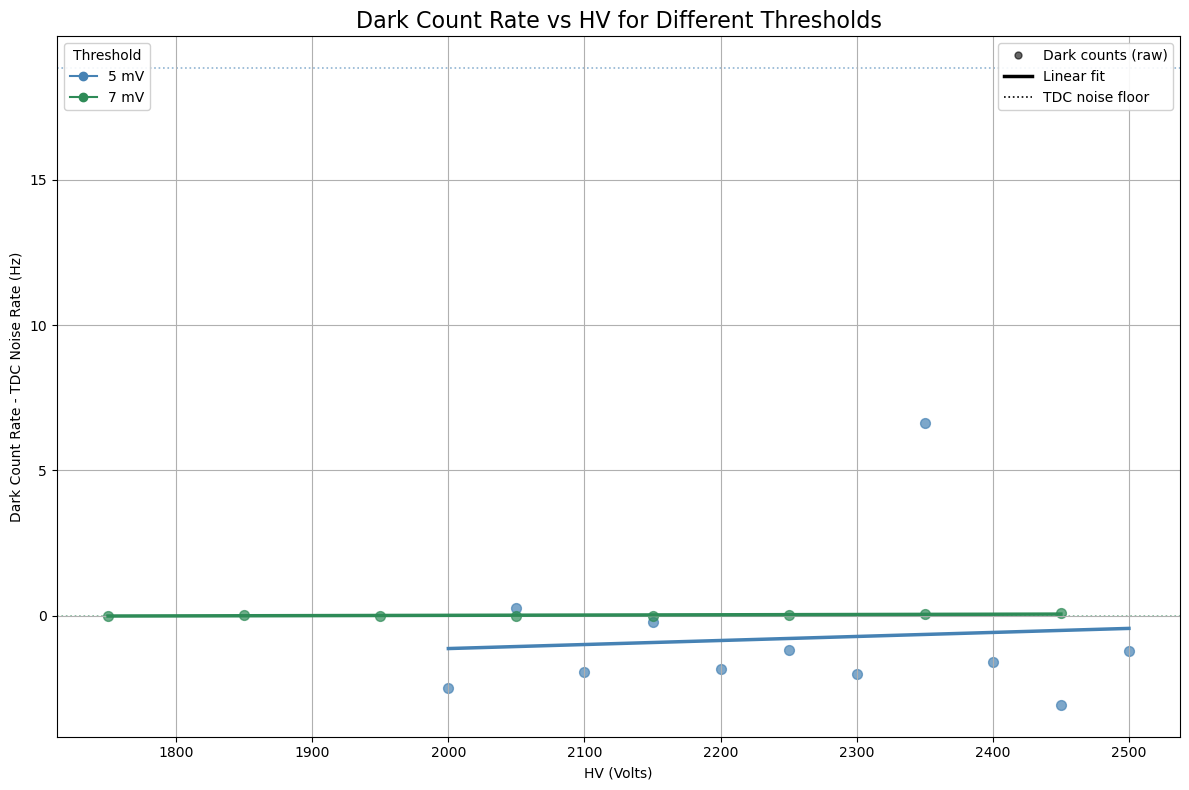

In [7]:


palette = plt.cm.tab10.colors
thresholds_sorted = sorted(dark_df['threshold_mv'].unique())
colors = {3: 'indianred', 5: 'steelblue', 7: 'seagreen'} 

fig, ax = plt.subplots(figsize=(12, 8))
for t in thresholds_sorted:
    sub = dark_df[dark_df['threshold_mv'] == t]
    color = colors[t]

    ax.scatter(sub['hv_volts'], sub['rate_minus_tdc_hz'], color=color, label=f'Threshold: {t} mV', s=50, alpha=0.7)
    
    if t in dark_fits:
        hv_range = np.linspace(sub["hv_volts"].min(), sub["hv_volts"].max(), 100)
        ax.plot(hv_range, dark_fits[t](hv_range), '-', color=color, linewidth=2.5, zorder=3)


    if t in tdc_noise_lookup:
        ax.axhline(y=tdc_noise_lookup[t][0], color=color, linestyle=':', linewidth=1.2, alpha=0.6, zorder=1)

ax.set_xlabel('HV (Volts)')
ax.set_ylabel('Dark Count Rate - TDC Noise Rate (Hz)')
ax.set_title('Dark Count Rate vs HV for Different Thresholds', fontsize = '16')
ax.grid()

color_handles = [mlines.Line2D([], [], color=colors[t], marker='o', linestyle='-',
                                 markersize=6, label=f"{t} mV") for t in thresholds_sorted]
legend1 = ax.legend(handles=color_handles, title="Threshold", loc="upper left", framealpha=0.9)
ax.add_artist(legend1)

style_handles = [
    mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=5,
                  alpha=0.6, label='Dark counts (raw)'),
    mlines.Line2D([], [], color='black', linestyle='-', linewidth=2.5, label='Linear fit'),
    mlines.Line2D([], [], color='black', linestyle=':', linewidth=1.2, label='TDC noise floor'),
]
ax.legend(handles=style_handles, loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.show()

# Average Pulse Height vs Detector Bias
29/06/26

Using Oscilliscope: -7mV Falling Edge Trigger
Average Acquisition Mode (512)
Measurement: Amplitude
4 ns, 10.0mV

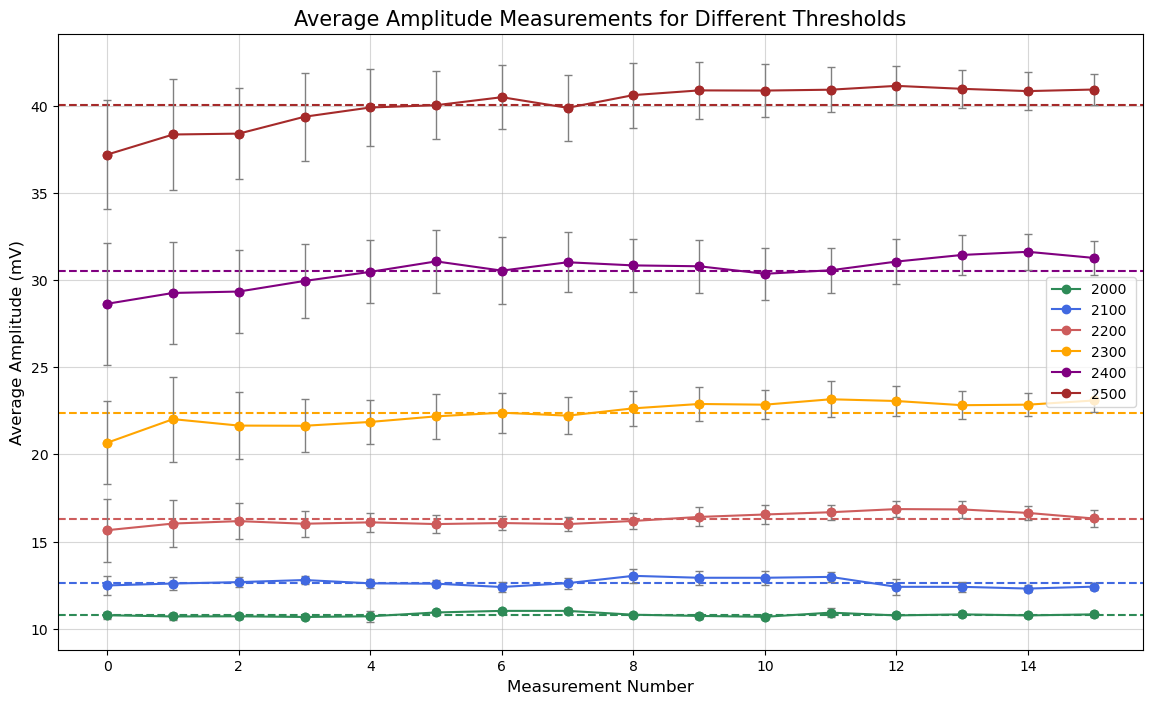

In [71]:
amp_2000 = [10.77, 10.70, 10.71, 10.67, 10.71, 10.93, 11.02, 11.02, 10.80, 10.73, 10.68, 10.92, 10.76, 10.82, 10.76, 10.82] 
std_2000 = [207.2, 213.2, 135.7, 125.8, 311.9, 148.4, 120.6, 138.2, 98.51, 189.6, 125.3, 253.8, 120.3, 105.9, 90.32, 134.7] # in microV

amp_2100 = [12.48, 12.59, 12.67, 12.79, 12.60, 12.58, 12.39, 12.61, 13.03, 12.92, 12.92, 12.97, 12.40, 12.40, 12.30, 12.41]
std_2100 = [535.8, 391.3, 283.5, 255.0, 264.5, 195.7, 265.5, 313.2, 396.6, 409.2, 401.4, 296.2, 469.4, 276.8, 188.4, 215.6] # in microV

amp_2200 = [15.65, 16.03, 16.17, 16.02, 16.10, 16.00, 16.06, 16.00, 16.18, 16.41, 16.55, 16.68, 16.86, 16.84, 16.64, 16.32]
std_2200 = [1.799, 1.348, 1.013, 0.737, 0.555, 0.515, 0.403, 0.420, 0.456, 0.542, 0.564, 0.440, 0.454, 0.471, 0.405, 0.516] # in mV

amp_2300 = [20.67, 22.02, 21.65, 21.64, 21.86, 22.18, 22.39, 22.22, 22.64, 22.89, 22.85, 23.16, 23.06, 22.82, 22.85, 23.09]
std_2300 = [2.363, 2.437, 1.931, 1.518, 1.275, 1.281, 1.154, 1.071, 1.012, 0.960, 0.830, 1.026, 0.841, 0.818, 0.675, 0.664] # in mV

amp_2400 = [28.64, 29.26, 29.34, 29.95, 30.47, 31.07, 30.54, 31.02, 30.84, 30.79, 30.36, 30.56, 31.06, 31.44, 31.62, 31.27]
std_2400 = [3.488, 2.915, 2.379, 2.102, 1.813, 1.788, 1.903, 1.720, 1.535, 1.526, 1.488, 1.302, 1.282, 1.168, 1.040, 0.973] # in mV

amp_2500 = [37.20, 38.35, 38.40, 39.37, 39.90, 40.03, 40.49, 39.88, 40.61, 40.88, 40.87, 40.92, 41.14, 40.97, 40.84, 40.93]
std_2500 = [3.121, 3.188, 2.608, 2.535, 2.229, 1.960, 1.841, 1.884, 1.864, 1.645, 1.511, 1.277, 1.119, 1.081, 1.070, 0.911] # in mV

# Quick Conversions from microV to mV for plotting error bars
cstd_2000 = [s / 1000 for s in std_2000]
cstd_2100 = [s / 1000 for s in std_2100]



plt.figure(figsize=(14, 8))
plt.plot(amp_2000, marker='o', linestyle='-', color='seagreen', label='2000 ')
plt.axhline(y=np.mean(amp_2000), color='seagreen', linestyle='--')
plt.errorbar(range(len(amp_2000)), amp_2000, yerr=cstd_2000, fmt='o', color='seagreen', ecolor='gray', elinewidth=1, capsize=3)
plt.plot(amp_2100, marker='o', linestyle='-', color='royalblue', label='2100 ')
plt.axhline(y=np.mean(amp_2100), color='royalblue', linestyle='--')
plt.errorbar(range(len(amp_2100)), amp_2100, yerr=cstd_2100, fmt='o', color='royalblue', ecolor='gray', elinewidth=1, capsize=3)
plt.plot(amp_2200, marker='o', linestyle='-', color='indianred', label='2200 ')
plt.axhline(y=np.mean(amp_2200), color='indianred', linestyle='--')
plt.errorbar(range(len(amp_2200)), amp_2200, yerr=std_2200, fmt='o', color='indianred', ecolor='gray', elinewidth=1, capsize=3)
plt.plot(amp_2300, marker='o', linestyle='-', color='orange', label='2300 ')
plt.axhline(y=np.mean(amp_2300), color='orange', linestyle='--')
plt.errorbar(range(len(amp_2300)), amp_2300, yerr=std_2300, fmt='o', color='orange', ecolor='gray', elinewidth=1, capsize=3)
plt.plot(amp_2400, marker='o', linestyle='-', color='purple', label='2400 ')
plt.axhline(y=np.mean(amp_2400), color='purple', linestyle='--')
plt.errorbar(range(len(amp_2400)), amp_2400, yerr=std_2400, fmt='o', color='purple', ecolor='gray', elinewidth=1, capsize=3)
plt.plot(amp_2500, marker='o', linestyle='-', color='brown', label='2500 ')
plt.axhline(y=np.mean(amp_2500), color='brown', linestyle='--')
plt.errorbar(range(len(amp_2500)), amp_2500, yerr=std_2500, fmt='o', color='brown', ecolor='gray', elinewidth=1, capsize=3)
plt.xlabel('Measurement Number', fontsize=12)
plt.ylabel('Average Amplitude (mV)', fontsize = 12)
plt.title('Average Amplitude Measurements for Different Thresholds', fontsize = 15)
plt.grid(alpha=0.5)
plt.legend()
plt.show()